<h4>Handel missing value by using different method

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('aug_train.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 2.

In [7]:
#Check null values
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [8]:
#Percentage of null values 
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
last_new_job               2.207955
training_hours             0.000000
target                     0.000000
dtype: float64

<h4>Extract those columns who has less then 5% of null values

In [10]:
cols=[col for col in df.columns if(df[col].isnull().mean()*100 < 5 and df[col].isnull().mean()*100 > 0)]

In [12]:
df[cols]

,enrolled_university,education_level,experience,last_new_job
0,no_enrollment,Graduate,>20,1
1,no_enrollment,Graduate,15,>4
2,Full time course,Graduate,5,never
3,NaN,Graduate,<1,never
4,no_enrollment,Masters,>20,4
...,...,...,...,...
19153,no_enrollment,Graduate,14,1
19154,no_enrollment,Graduate,14,4
19155,no_enrollment,Graduate,>20,4
19156,no_enrollment,High School,<1,2


<h4>Percentage after CCA

In [13]:
len(df[cols].dropna())/len(df)*100

94.02860423843825

In [14]:
new_df=df[cols].dropna()

In [18]:
#Before dropna len of dataset
print('Before CCA',df.shape)
print('After CCA',new_df.shape)

Before CCA (19158, 14)
After CCA (18014, 4)


<h4>Histogram compare both of datasets

<Axes: >

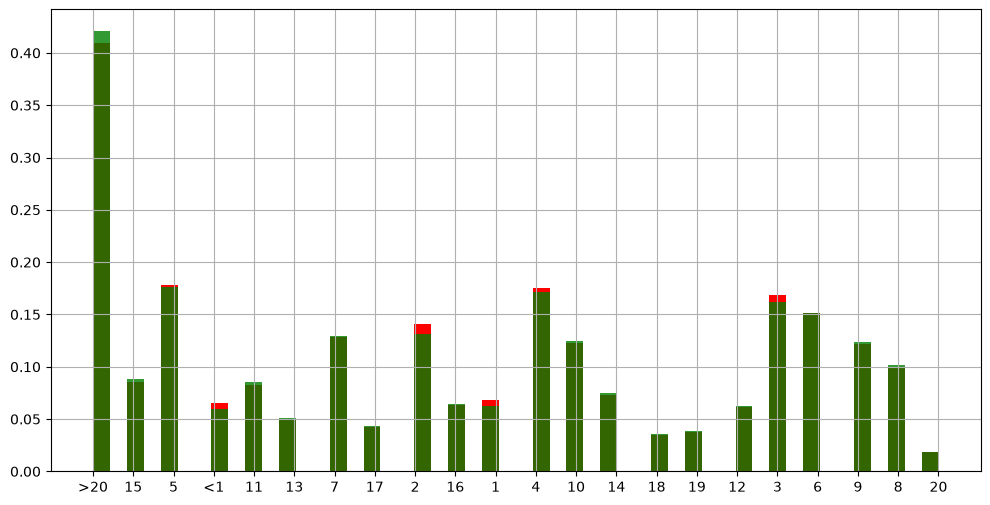

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

df['experience'].hist(bins=50, ax=ax, density=True, color='red')
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<h4>CCA use when the data is MCAR and less the 5% of value is null